In [58]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import tensorflow as tf

from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
data = pd.read_csv("spam_dataset.csv")
data

,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1
...,...,...
995,"Hello Virginia,\n\nIt was great to catch up wi...",0
996,Final notice: Claim your inheritance from a di...,1
997,Hot singles in your area want to chat! Contact...,1
998,Your loan has been approved! Transfer funds to...,1


In [7]:
data.is_spam.value_counts()

is_spam
0    500
1    500
Name: count, dtype: int64

In [10]:
n = 100
print(data.message_content[n], data.is_spam[n], sep="\n\n ")

Urgent! Your account has been compromised. Verify your identity immediately.

Your account has been selected for a special reward. Click here to claim it now!

For more details, visit our website or contact us directly.

 1


In [27]:
t = Tokenizer()
t.fit_on_texts(data.message_content)

In [28]:
len(t.word_index)

1798

In [29]:
dict(sorted(t.word_counts.items(), key=lambda x: x[1], reverse=True))

{'to': 1915,
 'you': 1640,
 'your': 1093,
 'please': 1055,
 'for': 995,
 'the': 934,
 'any': 886,
 'have': 865,
 'out': 795,
 'details': 774,
 'questions': 765,
 'if': 764,
 'our': 753,
 'free': 715,
 'reach': 578,
 'feel': 577,
 'or': 577,
 'i': 549,
 'more': 540,
 'us': 531,
 'a': 530,
 'contact': 516,
 'visit': 514,
 'website': 500,
 'directly': 500,
 'on': 436,
 'this': 396,
 'attached': 375,
 'now': 366,
 'with': 299,
 'let': 287,
 'it': 286,
 'know': 285,
 'act': 265,
 'me': 254,
 'click': 251,
 'here': 242,
 'just': 233,
 'and': 225,
 'project': 224,
 'is': 224,
 'provide': 214,
 'offer': 211,
 'miss': 211,
 'next': 205,
 'time': 195,
 'wanted': 194,
 'thank': 191,
 'about': 189,
 'get': 187,
 'review': 187,
 'up': 184,
 'been': 183,
 'claim': 179,
 'account': 179,
 'limited': 176,
 'feedback': 175,
 'best': 174,
 'regards': 171,
 'hi': 167,
 'special': 164,
 'forward': 160,
 'find': 159,
 'don’t': 153,
 'need': 151,
 'one': 151,
 'help': 142,
 'follow': 135,
 'can': 135,
 'win'

In [37]:
new_text = t.texts_to_sequences(data.message_content)
new_text

[[84,
  1446,
  38,
  47,
  1,
  267,
  234,
  106,
  13,
  268,
  45,
  85,
  4,
  63,
  6,
  10,
  154,
  110,
  785,
  685,
  302,
  285,
  900,
  457,
  901,
  530,
  115,
  165,
  686,
  403,
  134,
  59,
  1206,
  1447,
  4,
  63,
  28,
  6,
  95,
  40,
  100,
  31,
  35,
  33,
  12,
  2,
  8,
  7,
  11,
  12,
  2,
  8,
  7,
  11,
  4,
  16,
  14,
  1,
  15,
  9],
 [201,
  159,
  192,
  21,
  202,
  162,
  20,
  29,
  1,
  54,
  32,
  3,
  55,
  73,
  53,
  96,
  5,
  21,
  61,
  127,
  36,
  37,
  1,
  54,
  32,
  29,
  5,
  19,
  10,
  23,
  13,
  24,
  17,
  22,
  20,
  25],
 [2,
  8,
  53,
  404,
  177,
  5,
  21,
  405,
  180,
  30,
  21,
  166,
  406,
  27,
  61,
  43,
  41,
  94,
  5,
  21,
  56,
  46,
  90,
  34,
  124,
  1,
  139,
  3,
  140,
  5,
  19,
  10,
  23,
  13,
  24,
  17,
  22,
  20,
  25],
 [56,
  46,
  43,
  34,
  29,
  90,
  21,
  211,
  274,
  203,
  121,
  107,
  122,
  76,
  3,
  55,
  10,
  1,
  77,
  123,
  5,
  19,
  10,
  23,
  13,
  24,
  17,
  22,


In [38]:
len(new_text)

1000

In [39]:
len(new_text[0])

60

In [43]:
lens = np.array([len(i) for i in new_text])

In [42]:
min(lens), max(lens)

(27, 86)

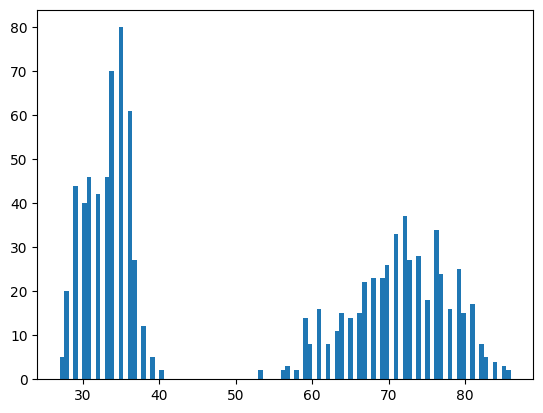

In [45]:
plt.hist(lens, bins=100);

In [46]:
new_text1 = t.texts_to_matrix(data.message_content)
new_text1

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 1.]], shape=(1000, 1799))

In [49]:
new_text1[0]

array([0., 1., 1., ..., 0., 0., 0.], shape=(1799,))

In [51]:
y = data.is_spam.values

In [55]:
x_train, x_test, y_train, y_test = train_test_split(new_text1, y, test_size=0.2, random_state=1)

In [64]:
model = LogisticRegression()
model.fit(x_train, y_train)
p_train = model.predict(x_train)
p_train_probs = model.predict_proba(x_train)
p_test = model.predict(x_test)
p_test_probs = model.predict_proba(x_test)
print(f"Train_acc={accuracy_score(y_train, p_train)}, test_acc={accuracy_score(y_test, p_test)}")
print(f"Train_AUC={roc_auc_score(y_train, p_train_probs[:, 1])}, test_AUC={roc_auc_score(y_test, p_test_probs[:, 1])}")

Train_acc=1.0, test_acc=1.0
Train_AUC=1.0, test_AUC=1.0
